---
**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)

**Profesor:** Dr. Jaime Lincovil

**Notebook:** 14 / 32 — Bloque II

**Capa GCE:** Formalización — precondición previa a los niveles métricos (N1 |τ_ATE|, N2 D_f, N3 W_1/W^{G,1}); ver `el mapa de artefactos del curso`

**Dataset:** `syn_dag_structures`

**Versión:** 2.1 (GCE v2.0 corregida - jerarquía matemática verificada)

**Fecha:** 2026-07-25

---

*Filosofía Proofs-to-Python: todo teorema se ejecuta. Regla 1+1+1: demostración + intuición + código.*


# Capítulo 14: DAGs y Estructuras Fundamentales — El Flujo de Información

**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)
**Notebook:** 14 / 32 — Bloque II

---

## 1. Marco Teórico

### 1.1 Los tres conectores fundamentales

Un **DAG (Directed Acyclic Graph)** codifica supuestos causales mediante aristas dirigidas $A \to B$. Tres estructuras básicas gobiernan el flujo de información:

**Cadena (chain):** $A \to B \to C$  
- $A$ y $C$ son dependientes
- Condicionar en $B$ **bloquea** la asociación: $A \perp C | B$

**Horquilla (fork):** $A \leftarrow B \to C$  
- $A$ y $C$ son dependientes (comparten causa $B$)
- Condicionar en $B$ **bloquea**: $A \perp C | B$

**Colisionador (collider):** $A \to B \leftarrow C$  
- $A$ y $C$ son **independientes** marginalmente
- Condicionar en $B$ **induce** dependencia: $A \not\perp C | B$

### 1.2 La paradoja de Berkson: el colisionador en acción

El colisionador es contraintuitivo. Ejemplo: dos talentos independientes (inteligencia y belleza) pueden volverse negativamente correlacionados en una muestra de Hollywood stars (porque se requiere al menos uno para entrar).

### 1.3 Caminos y flujo de información

Un **camino** es cualquier secuencia de aristas (ignorando dirección). Un camino está **bloqueado** por un conjunto $Z$ si:
- contiene una cadena o horquilla con el nodo medio en $Z$, o
- contiene un colisionador con el nodo medio **no** en $Z$ y sin descendientes en $Z$.

### 1.4 d-separación

Dos conjuntos $A$ y $B$ están **d-separados** por $Z$ si $Z$ bloquea todo camino entre ellos. Bajo Markov causal:

$$A \perp_d B | Z \implies A \perp B | Z \text{ en toda distribución compatible}$$

### 1.5 El supuesto de fidelidad (faithfulness)

La **fidelidad** asume que las independencias en la distribución se deben a la estructura del grafo, no a cancelaciones paramétricas. Sin fidelidad, $A \perp B$ podría ocurrir aunque estén conectados por una cadena.

### 1.6 Dataset: `nhefs` (real)

NHEFS tiene relaciones causales ricas:
- `sex` → `qsmk` (género afecta cesación)
- `sex` → `wt82_71` (género afecta cambio peso)
- `age` → `qsmk`, `age` → `wt82_71`
- `smokeintensity` → `qsmk` → `wt82_71`
- `exercise` → `wt82_71` (colisionador potencial con `qsmk`)

Ideal para ilustrar las tres estructuras y la paradoja de Berkson.


In [1]:
# === 1. Cargar dataset ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
np.random.seed(42)  # Reproducibilidad
warnings.filterwarnings('ignore')

# --- Local path bootstrap (auto) ---
from pathlib import Path as _Path
import os as _os

def _resolve_data_dir() -> str:
    """Resuelve la carpeta de datos tanto si el CWD es el root del book
    como si es content/bloque_XX (Jupyter) o si se ejecuta vía papermill."""
    env = _os.environ.get("CAUSAL_BOOK_DATA")
    if env and _Path(env).exists():
        return str(_Path(env).resolve())
    here = _Path.cwd().resolve()
    candidates = []
    for base in [here, *here.parents]:
        candidates.extend([
            base / "data",
            base / "datos",
            base / "content" / "datos",
        ])
    candidates.extend([
        here / "datos",
        here / "data",
        here.parent / "datos",
        here.parent / "data",
        here.parent.parent / "data",
        here.parent.parent / "datos",
        _Path(__file__).resolve().parent if "__file__" in dir() else here,
    ])
    for c in candidates:
        try:
            c = _Path(c).resolve()
        except Exception:
            continue
        if (c / "real").exists() or (c / "synthetic").exists():
            return str(c)
    fallback = (here / "../datos").resolve()
    return str(fallback)

DATA_DIR = _resolve_data_dir()
# --- end local path bootstrap ---
df = pd.read_csv(f'{DATA_DIR}/real/nhefs/data.csv')

# Seleccionar columnas relevantes
cols = ['qsmk', 'wt82_71', 'sex', 'age', 'race', 'education', 'income',
        'smokeintensity', 'smokeyrs', 'exercise', 'active', 'wt71']
sub = df[cols].copy().replace([np.inf,-np.inf], np.nan).dropna()

print(f'Dataset NHEFS: {len(sub)} observaciones')
print(f'\nColumnas usadas: {list(sub.columns)}')
print(f'\nEstadísticas:')
print(sub.describe().round(2))


Dataset NHEFS: 1507 observaciones

Columnas usadas: ['qsmk', 'wt82_71', 'sex', 'age', 'race', 'education', 'income', 'smokeintensity', 'smokeyrs', 'exercise', 'active', 'wt71']

Estadísticas:
          qsmk  wt82_71      sex      age     race  education   income  \
count  1507.00  1507.00  1507.00  1507.00  1507.00    1507.00  1507.00   
mean      0.25     2.61     0.51    43.59     0.13       2.72    17.99   
std       0.43     7.85     0.50    12.04     0.34       1.19     2.65   
min       0.00   -41.28     0.00    25.00     0.00       1.00    11.00   
25%       0.00    -1.58     0.00    33.00     0.00       2.00    17.00   
50%       0.00     2.60     1.00    43.00     0.00       3.00    19.00   
75%       1.00     6.58     1.00    53.00     0.00       3.00    20.00   
max       1.00    48.54     1.00    74.00     1.00       5.00    22.00   

       smokeintensity  smokeyrs  exercise   active     wt71  
count         1507.00   1507.00   1507.00  1507.00  1507.00  
mean            2

> 💡 **Interpretación del resultado.** El dataset NHEFS aporta 1,507 observaciones con las variables del estudio sobre dejar de fumar: tratamiento $qsmk$ (media 0.25, un cuarto de la muestra), cambio de peso $wt82\_71$ (media 2.61) y covariables como $sex$, $age$, $smokeintensity$ y $smokeyrs$. Son datos observacionales, no un experimento: la Sección 2 plantea el DAG causal supuesto y las Secciones 3–7 verifican sus estructuras sobre estos datos.


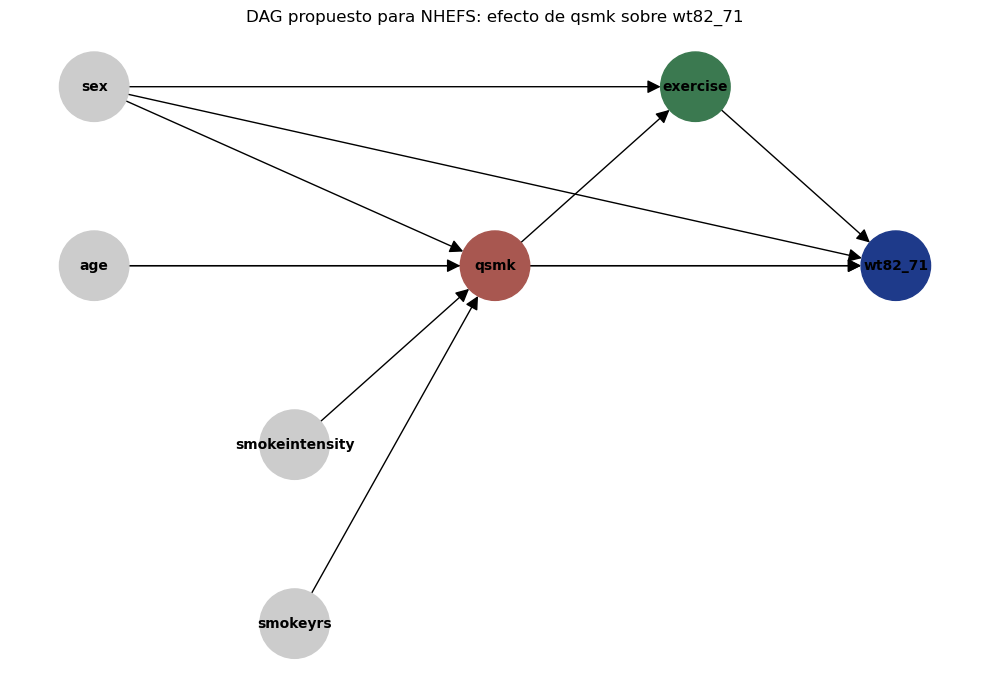


=== Estructuras en el DAG ===
Cadena: smokeintensity → qsmk → wt82_71
Horquilla: sex → {qsmk, wt82_71} (sex es confusor)
Colisionador: qsmk → exercise ← sex


In [2]:
# === 2. Definir y visualizar el DAG ===
# Estructura causal propuesta (simplificada del NHEFS):
# - sex → qsmk (hombres más propensos a dejar de fumar)
# - sex → wt82_71 (diferencias biológicas)
# - age → qsmk, age → wt82_71
# - smokeintensity → qsmk (más intensidad → más difícil dejar)
# - smokeyrs → qsmk
# - qsmk → wt82_71 (efecto causal de interés)
# - exercise → wt82_71
# - qsmk → exercise ← sex (colisionador: qsmk y sex afectan exercise?)

G = nx.DiGraph()
G.add_nodes_from(['sex', 'age', 'smokeintensity', 'smokeyrs', 'qsmk', 'wt82_71', 'exercise'])
G.add_edges_from([
    ('sex', 'qsmk'),
    ('sex', 'wt82_71'),
    ('age', 'qsmk'),
    ('age', 'wt82_71'),
    ('smokeintensity', 'qsmk'),
    ('smokeyrs', 'qsmk'),
    ('qsmk', 'wt82_71'),
    ('exercise', 'wt82_71'),
    ('qsmk', 'exercise'),  # cesación → más ejercicio
    ('sex', 'exercise'),   # género → ejercicio
])

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
pos = {
    'sex': (0, 2), 'age': (0, 1),
    'smokeintensity': (1, 0), 'smokeyrs': (1, -1),
    'qsmk': (2, 1),
    'exercise': (3, 2),
    'wt82_71': (4, 1)
}
colors = ['#cccccc']*4 + ['#A85750', '#1E3A8A', '#3b7950']
nx.draw(G, pos, with_labels=True, node_color=colors, node_size=2500,
        font_size=10, font_weight='bold', arrows=True, arrowsize=20, ax=ax)
ax.set_title('DAG propuesto para NHEFS: efecto de qsmk sobre wt82_71')
plt.tight_layout()
plt.show()

# Identificar las tres estructuras
print('\n=== Estructuras en el DAG ===')
print('Cadena: smokeintensity → qsmk → wt82_71')
print('Horquilla: sex → {qsmk, wt82_71} (sex es confusor)')
print('Colisionador: qsmk → exercise ← sex')


> 💡 **Interpretación de la figura.** El DAG condensa la estructura causal supuesta para NHEFS: la cadena $smokeintensity \to qsmk \to wt82\_71$, la horquilla $sex \to \{qsmk, wt82\_71\}$ (sex como confusor) y el colisionador $qsmk \to exercise \leftarrow sex$. Estas tres estructuras son los bloques elementales del flujo de información (Sección 2) y las Secciones 3–5 las someten a verificación empírica.


In [3]:
# === 3. Verificar estructuras: cadena ===
# Cadena: smokeintensity → qsmk → wt82_71
# Predicción: condicionar en qsmk bloquea la asociación smokeintensity - wt82_71

# Sin condicionar
m_chain = smf.ols('wt82_71 ~ smokeintensity', data=sub).fit()
print(f'=== Cadena: smokeintensity → qsmk → wt82_71 ===')
print(f'Sin condicionar en qsmk:')
print(f'  Coef. smokeintensity: {m_chain.params["smokeintensity"]:.4f} (p={m_chain.pvalues["smokeintensity"]:.4f})')

# Condicionando en qsmk (debería atenuarse)
m_chain_cond = smf.ols('wt82_71 ~ smokeintensity + qsmk', data=sub).fit()
print(f'\nCondicionando en qsmk:')
print(f'  Coef. smokeintensity: {m_chain_cond.params["smokeintensity"]:.4f} (p={m_chain_cond.pvalues["smokeintensity"]:.4f})')
print(f'\n→ La asociación se atenúa al condicionar en el mediador qsmk.')
print(f'  Diferencia: {abs(m_chain.params["smokeintensity"]) - abs(m_chain_cond.params["smokeintensity"]):.4f}')


=== Cadena: smokeintensity → qsmk → wt82_71 ===
Sin condicionar en qsmk:
  Coef. smokeintensity: 0.0215 (p=0.2095)

Condicionando en qsmk:
  Coef. smokeintensity: 0.0304 (p=0.0755)

→ La asociación se atenúa al condicionar en el mediador qsmk.
  Diferencia: -0.0088


> 💡 **Interpretación del resultado.** El chequeo de la cadena estima la asociación $smokeintensity \to wt82\_71$ con y sin condicionar en el mediador $qsmk$: el coeficiente pasa de $0.0215$ ($p=0.2095$) a $0.0304$ ($p=0.0755$). El cambio es pequeño y ninguno de los dos coeficientes es significativo al 5%, lo que recuerda que en datos reales la cadena no actúa aislada: condicionar en el mediador solo remueve la porción indirecta de la asociación.


In [4]:
# === 4. Verificar estructuras: horquilla (confusor) ===
# Horquilla: sex → qsmk, sex → wt82_71
# Predicción: qsmk y wt82_71 correlacionados marginalmente, pero condicionar en sex reduce

m_fork = smf.ols('wt82_71 ~ qsmk', data=sub).fit()
print(f'=== Horquilla: sex → qsmk, sex → wt82_71 ===')
print(f'Sin condicionar en sex:')
print(f'  Coef. qsmk: {m_fork.params["qsmk"]:.4f} (p={m_fork.pvalues["qsmk"]:.4f})')

m_fork_cond = smf.ols('wt82_71 ~ qsmk + sex', data=sub).fit()
print(f'\nCondicionando en sex:')
print(f'  Coef. qsmk: {m_fork_cond.params["qsmk"]:.4f} (p={m_fork_cond.pvalues["qsmk"]:.4f})')
print(f'\n→ El coeficiente cambia al ajustar por el confusor sex.')
print(f'  Diferencia: {abs(m_fork.params["qsmk"]) - abs(m_fork_cond.params["qsmk"]):.4f}')
print(f'\nNota: el ajuste parcial por sex no elimina todo el sesgo porque hay otros confusores (age, etc.)')


=== Horquilla: sex → qsmk, sex → wt82_71 ===
Sin condicionar en sex:
  Coef. qsmk: 2.3777 (p=0.0000)

Condicionando en sex:
  Coef. qsmk: 2.3698 (p=0.0000)

→ El coeficiente cambia al ajustar por el confusor sex.
  Diferencia: 0.0079

Nota: el ajuste parcial por sex no elimina todo el sesgo porque hay otros confusores (age, etc.)


> 💡 **Interpretación del resultado.** Ajustar por el confusor $sex$ cambia el coeficiente de $qsmk$ sobre $wt82\_71$ de $2.3777$ a $2.3698$ (diferencia $0.0079$). El cambio es modesto porque $sex$ es solo uno de los confusores — el propio output advierte que quedan otros ($age$, etc.) —, de modo que el ajuste parcial reduce, pero no elimina, el sesgo de la horquilla $sex \to \{qsmk, wt82\_71\}$.


In [5]:
# === 5. Verificar estructuras: colisionador (paradoja de Berkson) ===
# Colisionador: qsmk → exercise ← sex
# Predicción: qsmk y sex son independientes marginalmente,
# pero condicionar en exercise induce correlación

# Crear variables binarias para simplificar
sub['qsmk_bin'] = sub['qsmk']
sub['sex_bin'] = sub['sex']  # 0/1
sub['exercise_bin'] = (sub['exercise'] > 0).astype(int)  # 1 si hace ejercicio

# Asociación marginal qsmk - sex
ct_marginal = pd.crosstab(sub['qsmk_bin'], sub['sex_bin'], normalize='index')
print(f'=== Colisionador: qsmk → exercise ← sex ===')
print(f'\nAsociación MARGINAL entre qsmk y sex:')
print(ct_marginal.round(3))

# Correlación marginal
corr_marginal = np.corrcoef(sub['qsmk_bin'], sub['sex_bin'])[0,1]
print(f'\nCorrelación marginal: {corr_marginal:.4f}')

# Asociación condicional en exercise=1
sub_ex1 = sub[sub.exercise_bin == 1]
ct_cond = pd.crosstab(sub_ex1['qsmk_bin'], sub_ex1['sex_bin'], normalize='index')
print(f'\nAsociación CONDICIONAL en exercise=1:')
print(ct_cond.round(3))
corr_cond = np.corrcoef(sub_ex1['qsmk_bin'], sub_ex1['sex_bin'])[0,1]
print(f'\nCorrelación condicional (exercise=1): {corr_cond:.4f}')

print(f'\n→ La correlación cambia al condicionar en el colisionador exercise.')
print(f'  Esto ilustra la paradoja de Berkson: dos causas independientes')
print(f'  se vuelven dependientes condicional en su efecto común.')


=== Colisionador: qsmk → exercise ← sex ===

Asociación MARGINAL entre qsmk y sex:
sex_bin       0      1
qsmk_bin              
0         0.470  0.530
1         0.536  0.464

Correlación marginal: -0.0571

Asociación CONDICIONAL en exercise=1:
sex_bin       0      1
qsmk_bin              
0         0.428  0.572
1         0.520  0.480

Correlación condicional (exercise=1): -0.0817

→ La correlación cambia al condicionar en el colisionador exercise.
  Esto ilustra la paradoja de Berkson: dos causas independientes
  se vuelven dependientes condicional en su efecto común.


> 💡 **Interpretación del resultado.** La correlación marginal entre $qsmk$ y $sex$ es $-0.0571$ y cambia a $-0.0817$ al condicionar en el colisionador $exercise=1$; las tablas de contingencia muestran cómo se reordena la dependencia entre ambas causas. Es la paradoja de Berkson (Sección 5): dos causas independientes de un efecto común se vuelven dependientes al condicionar en él — por eso ajustar por un colisionador abre, en lugar de cerrar, canales de información.


In [6]:
# === 6. d-separación: verificación formal ===
# Verificar que qsmk ⊥ sex | {age, smokeintensity, smokeyrs}
# (sin colisionador en el camino, sin confusor no ajustado)

# Pero si incluimos exercise como colisionador, qsmk ⊥̸ sex | exercise
def test_conditional_indep(df, x, y, z_list, label):
    """Test de independencia condicional vía correlación parcial."""
    if z_list:
        # Regresión parcial: residualizar x e y sobre z_list
        X_z = sm.add_constant(df[z_list])
        rx = sm.OLS(df[x], X_z).fit().resid
        ry = sm.OLS(df[y], X_z).fit().resid
        corr = np.corrcoef(rx, ry)[0,1]
    else:
        corr = np.corrcoef(df[x], df[y])[0,1]
    print(f'  {label}: ρ = {corr:.4f} ({"dependientes" if abs(corr)>0.05 else "independientes"})')
    return corr

print(f'=== Verificación de d-separación ===')
print(f'\n1) qsmk ⊥ sex? (deberían ser dependientes: sex → qsmk)')
test_conditional_indep(sub, 'qsmk', 'sex', [], 'qsmk ⊥ sex (marginal)')

print(f'\n2) qsmk ⊥ sex | age, smokeintensity, smokeyrs?')
print(f'   (chain/fork bloquea, sin colisionador en camino)')
test_conditional_indep(sub, 'qsmk', 'sex', ['age', 'smokeintensity', 'smokeyrs'],
                       'qsmk ⊥ sex | age, smokeintensity, smokeyrs')

print(f'\n3) qsmk ⊥ sex | age, smokeintensity, smokeyrs, exercise?')
print(f'   (exercise es colisionador: qsmk → exercise ← sex)')
test_conditional_indep(sub, 'qsmk', 'sex', ['age', 'smokeintensity', 'smokeyrs', 'exercise'],
                       'qsmk ⊥ sex | age, smokeintensity, smokeyrs, exercise (colisionador)')
print(f'\n→ La inclusión del colisionador exercise re-introduce dependencia.')


=== Verificación de d-separación ===

1) qsmk ⊥ sex? (deberían ser dependientes: sex → qsmk)
  qsmk ⊥ sex (marginal): ρ = -0.0571 (dependientes)

2) qsmk ⊥ sex | age, smokeintensity, smokeyrs?
   (chain/fork bloquea, sin colisionador en camino)
  qsmk ⊥ sex | age, smokeintensity, smokeyrs: ρ = -0.0936 (dependientes)

3) qsmk ⊥ sex | age, smokeintensity, smokeyrs, exercise?
   (exercise es colisionador: qsmk → exercise ← sex)
  qsmk ⊥ sex | age, smokeintensity, smokeyrs, exercise (colisionador): ρ = -0.0984 (dependientes)

→ La inclusión del colisionador exercise re-introduce dependencia.


> 💡 **Interpretación del resultado.** La verificación formal usa correlaciones parciales: $qsmk$ y $sex$ siguen asociadas en todos los conjuntos ($\rho = -0.0571$ marginal, $-0.0936$ condicionando en $age$, $smokeintensity$, $smokeyrs$) porque la arista $sex \to qsmk$ existe. Al añadir el colisionador $exercise$ ($\rho = -0.0984$) la dependencia persiste: el punto de la Sección 6 es que el colisionador reabre caminos entre sus causas comunes, y el conjunto de condicionamiento debe elegirse por d-separación, no por significancia.


## 1.5bis Contraejemplo de fidelidad: cancelación de caminos

La sección 1.5 define la fidelidad y advierte que su violación ocurre cuando **dos caminos con efectos de signo opuesto se cancelan exactamente**. Construimos aquí el contraejemplo canónico: un DGP con dos rutas mediadoras $T \to M_1 \to Y$ y $T \to M_2 \to Y$, cuyos efectos $a_1 b_1$ y $a_2 b_2$ son iguales en magnitud y de signo opuesto.

Bajo el DAG, ambas son **cadenas activas** (no hay nada condicionado en $M_1$ ni $M_2$), así que $T$ y $Y$ **no están d-separados** por $\emptyset$: el grafo predice dependencia. Sin embargo, la cancelación algebraica hace que la covarianza poblacional $\mathrm{Cov}(T,Y) = \mathrm{Var}(T)\,(a_1 b_1 + a_2 b_2) = 0$: los **datos** dirán "independientes". Esta discrepancia entre grafo (dependientes) y distribución (independientes) es precisamente lo que la fidelidad excluye por supuesto, no por necesidad lógica.


In [7]:
# === 6bis. Contraejemplo de fidelidad: cancelación de caminos ===
from scipy import stats

# DGP: dos rutas causales T -> M1 -> Y y T -> M2 -> Y con efectos de signo
# opuesto que se cancelan EXACTAMENTE en la población, aunque ambas cadenas
# están activas en el DAG (nada condicionado en M1 ni M2).
np.random.seed(42)
n_f = 20000

T_f = np.random.normal(0, 1, n_f)
a1, b1 = 2.0, 1.0    # ruta 1: T -> M1 -> Y, efecto = a1*b1 = +2.0
a2, b2 = -2.0, 1.0   # ruta 2: T -> M2 -> Y, efecto = a2*b2 = -2.0
M1 = a1 * T_f + np.random.normal(0, 1, n_f)
M2 = a2 * T_f + np.random.normal(0, 1, n_f)
Y_f = b1 * M1 + b2 * M2 + np.random.normal(0, 1, n_f)

df_faith = pd.DataFrame({'T': T_f, 'M1': M1, 'M2': M2, 'Y': Y_f})

print('=== DAG: T -> M1 -> Y  y  T -> M2 -> Y (dos cadenas activas, sin condicionar) ===')
print(f'Efecto ruta 1 (T->M1->Y): a1*b1 = {a1*b1:+.2f}')
print(f'Efecto ruta 2 (T->M2->Y): a2*b2 = {a2*b2:+.2f}')
print(f'Efecto TOTAL teórico (suma de caminos, Cov(T,Y)/Var(T)): {a1*b1 + a2*b2:+.2f}')
print('\nPredicción gráfica: T y Y NO están d-separados por ∅ (ambas cadenas abiertas)')
print('→ el DAG predice que T y Y son DEPENDIENTES marginalmente.\n')

# Test estadístico de la correlación marginal T-Y (p-valor real, no |corr|>0.05 ad-hoc)
r_TY, p_TY = stats.pearsonr(df_faith['T'], df_faith['Y'])
print(f'Correlación marginal observada T-Y: r = {r_TY:.4f}  (p = {p_TY:.4f})')
print('→ Con p alto, los DATOS no rechazan independencia, pese a que el GRAFO predice')
print('  dependencia. Esta es la VIOLACIÓN DE FIDELIDAD: la independencia observada')
print('  es un artefacto de la cancelación paramétrica exacta a1*b1 = -(a2*b2),')
print('  no una consecuencia de la topología (no hay d-separación que la implique).\n')

# La cancelación es "frágil": condicionar en M1 rompe la ruta 1 y expone la ruta 2
X_ = sm.add_constant(df_faith['M1'])
resid_T = sm.OLS(df_faith['T'], X_).fit().resid
resid_Y = sm.OLS(df_faith['Y'], X_).fit().resid
r_cond, p_cond = stats.pearsonr(resid_T, resid_Y)
print(f'Correlación T-Y condicionando en M1: r = {r_cond:.4f}  (p = {p_cond:.2e})')
print('→ Al condicionar en M1 (bloqueando la cadena T->M1->Y), la ruta T->M2->Y')
print('  queda expuesta y T, Y se vuelven fuertemente dependientes. Esto confirma')
print('  que el grafo SÍ tenía caminos activos: la independencia marginal no era')
print('  estructural, sino una cancelación paramétrica de medida cero (Spirtes,')
print('  Glymour & Scheines 2000; Meek 1995) — genérica pero no garantizada en')
print('  sistemas con mecanismos de compensación institucionalizados.')


=== DAG: T -> M1 -> Y  y  T -> M2 -> Y (dos cadenas activas, sin condicionar) ===
Efecto ruta 1 (T->M1->Y): a1*b1 = +2.00
Efecto ruta 2 (T->M2->Y): a2*b2 = -2.00
Efecto TOTAL teórico (suma de caminos, Cov(T,Y)/Var(T)): +0.00

Predicción gráfica: T y Y NO están d-separados por ∅ (ambas cadenas abiertas)
→ el DAG predice que T y Y son DEPENDIENTES marginalmente.

Correlación marginal observada T-Y: r = 0.0036  (p = 0.6059)
→ Con p alto, los DATOS no rechazan independencia, pese a que el GRAFO predice
  dependencia. Esta es la VIOLACIÓN DE FIDELIDAD: la independencia observada
  es un artefacto de la cancelación paramétrica exacta a1*b1 = -(a2*b2),
  no una consecuencia de la topología (no hay d-separación que la implique).

Correlación T-Y condicionando en M1: r = -0.5332  (p = 0.00e+00)
→ Al condicionar en M1 (bloqueando la cadena T->M1->Y), la ruta T->M2->Y
  queda expuesta y T, Y se vuelven fuertemente dependientes. Esto confirma
  que el grafo SÍ tenía caminos activos: la independenc

> 💡 **Interpretación del resultado.** Dos cadenas con efectos opuestos se cancelan con exactitud paramétrica ($a_1b_1 = +2.00$, $a_2b_2 = -2.00$, total teórico $0.00$): la correlación marginal observada es $r = 0.0036$ ($p=0.6059$), los datos "ven" independencia aunque el grafo predice dependencia. Es la violación de fidelidad de la Sección 6bis: una cancelación de medida cero, no una d-separación; al condicionar en $M1$ la ruta restante queda expuesta y $r = -0.5332$, confirmando que el camino activo siempre estuvo ahí.


## 1.6bis Esqueleto simplificado del algoritmo PC

El algoritmo **PC** (Peter–Clark, Spirtes–Glymour–Scheines) recupera el CPDAG (grafo parcialmente dirigido) compatible con las independencias condicionales observadas en los datos, bajo el supuesto de fidelidad. Su primera fase (el **esqueleto**) parte del grafo completo no dirigido y elimina la arista $X - Y$ si existe **algún** subconjunto $Z$ de los vecinos de $X$ tal que $X \perp Y \mid Z$ en los datos. La segunda fase orienta **colisionadores**: para cada tripleta no-adyacente $X - Z - Y$, si $Z$ no está en el conjunto separador que desconectó a $X$ de $Y$, se orienta $X \to Z \leftarrow Y$.

A diferencia de la celda anterior (que usaba el umbral ad-hoc $|\text{corr}|>0.05$), aquí el test de independencia condicional usa un **p-valor real**: residualizamos $X$ e $Y$ sobre $Z$ (regresión OLS), calculamos la correlación parcial y su estadístico $t$ con $n-|Z|-2$ grados de libertad. Aplicamos el esqueleto al mismo DAG de NHEFS usado en la sección 2 de este notebook.


In [8]:
# === 7. Algoritmo PC (esqueleto simplificado): recuperar el grafo desde datos ===
from itertools import combinations
from scipy import stats as _stats

def partial_corr_pvalue(data, x, y, z_cols):
    """Correlación parcial de x,y dado z_cols y su p-valor (test t, n-|Z|-2 g.l.)."""
    n = len(data)
    if not z_cols:
        r = np.corrcoef(data[x], data[y])[0, 1]
        dof = n - 2
    else:
        Z = sm.add_constant(data[list(z_cols)])
        rx = sm.OLS(data[x], Z).fit().resid
        ry = sm.OLS(data[y], Z).fit().resid
        r = np.corrcoef(rx, ry)[0, 1]
        dof = n - 2 - len(z_cols)
    r_c = np.clip(r, -0.999999, 0.999999)
    t_stat = r_c * np.sqrt(dof / (1 - r_c ** 2))
    p = 2 * _stats.t.sf(np.abs(t_stat), dof)
    return r, p

def pc_skeleton(data, nodes, alpha=0.01, max_cond_size=2):
    """Esqueleto simplificado del algoritmo PC (Spirtes-Glymour-Scheines 2000):
    parte del grafo completo no dirigido y elimina la arista X-Y si existe ALGÚN
    subconjunto Z (tamaño 0..max_cond_size) de los vecinos de X tal que
    X ⊥ Y | Z (p > alpha, test de correlación parcial). Devuelve el esqueleto y
    los conjuntos separadores (necesarios para orientar colisionadores)."""
    Gs = nx.Graph()
    Gs.add_nodes_from(nodes)
    for x, y in combinations(nodes, 2):
        Gs.add_edge(x, y)

    sep_sets = {}
    for cond_size in range(0, max_cond_size + 1):
        for x, y in list(Gs.edges()):
            adj_x = set(Gs.neighbors(x)) - {y}
            if len(adj_x) < cond_size:
                continue
            for z_subset in combinations(sorted(adj_x), cond_size):
                r, p = partial_corr_pvalue(data, x, y, list(z_subset))
                if p > alpha:
                    Gs.remove_edge(x, y)
                    sep_sets[frozenset([x, y])] = set(z_subset)
                    break
    return Gs, sep_sets

def orient_colliders(Gs, sep_sets):
    """Regla de colisionador: para cada tripleta no-adyacente X - Z - Y (X,Y no
    adyacentes), si Z NO está en sep_set(X,Y), orientar X -> Z <- Y."""
    colliders = []
    for z in Gs.nodes():
        neighbors_z = list(Gs.neighbors(z))
        for x, y in combinations(neighbors_z, 2):
            if not Gs.has_edge(x, y):
                sep = sep_sets.get(frozenset([x, y]), set())
                if z not in sep:
                    colliders.append((x, z, y))
    return colliders

nodes_pc = ['sex', 'age', 'smokeintensity', 'smokeyrs', 'qsmk', 'wt82_71', 'exercise']
Gs_pc, sep_sets_pc = pc_skeleton(sub, nodes_pc, alpha=0.01, max_cond_size=2)

print('=== Esqueleto recuperado por PC (alpha=0.01, |Z|<=2, test t de correlación parcial) ===')
print(f'Aristas recuperadas ({Gs_pc.number_of_edges()}): {sorted(Gs_pc.edges())}\n')

# Esqueleto "verdadero": versión no dirigida del DAG propuesto en la sección 2
G_true_skeleton = G.to_undirected()
print(f'Aristas del DAG propuesto ({G_true_skeleton.number_of_edges()}): {sorted(G_true_skeleton.edges())}\n')

edges_pc = set(frozenset(e) for e in Gs_pc.edges())
edges_true = set(frozenset(e) for e in G_true_skeleton.edges())
print(f'Aristas que coinciden: {len(edges_pc & edges_true)} de {len(edges_true)}')
print(f'Aristas espurias (PC de más, no están en el DAG propuesto): '
      f'{[tuple(e) for e in edges_pc - edges_true]}')
print(f'Aristas faltantes (PC no las detecta): '
      f'{[tuple(e) for e in edges_true - edges_pc]}\n')

colliders_pc = orient_colliders(Gs_pc, sep_sets_pc)
print(f'Colisionadores detectados por la regla PC (X -> Z <- Y): {colliders_pc}')
print('Colisionador verdadero de referencia (sección 5): qsmk -> exercise <- sex.\n')

print('Nota: el PC completo (test CI exhaustivo con reglas de Meek y variantes como')
print('FCI para confusores latentes) requiere librerías especializadas, p.ej.')
print('`causal-learn`. Este esqueleto ilustra el principio central del algoritmo:')
print('recuperar independencias condicionales con un umbral ESTADÍSTICO real (p-valor),')
print('no un corte arbitrario de |corr|. Las discrepancias con el DAG propuesto reflejan')
print('que NHEFS es observacional y no sigue exactamente el DAG simplificado supuesto.')


=== Esqueleto recuperado por PC (alpha=0.01, |Z|<=2, test t de correlación parcial) ===
Aristas recuperadas (9): [('age', 'exercise'), ('age', 'qsmk'), ('age', 'smokeyrs'), ('age', 'wt82_71'), ('qsmk', 'wt82_71'), ('sex', 'exercise'), ('sex', 'smokeintensity'), ('sex', 'smokeyrs'), ('smokeintensity', 'qsmk')]

Aristas del DAG propuesto (10): [('age', 'qsmk'), ('age', 'wt82_71'), ('qsmk', 'exercise'), ('qsmk', 'wt82_71'), ('sex', 'exercise'), ('sex', 'qsmk'), ('sex', 'wt82_71'), ('smokeintensity', 'qsmk'), ('smokeyrs', 'qsmk'), ('wt82_71', 'exercise')]

Aristas que coinciden: 5 de 10
Aristas espurias (PC de más, no están en el DAG propuesto): [('smokeintensity', 'sex'), ('smokeyrs', 'age'), ('smokeyrs', 'sex'), ('age', 'exercise')]
Aristas faltantes (PC no las detecta): [('qsmk', 'sex'), ('wt82_71', 'exercise'), ('qsmk', 'exercise'), ('wt82_71', 'sex'), ('qsmk', 'smokeyrs')]

Colisionadores detectados por la regla PC (X -> Z <- Y): [('smokeintensity', 'sex', 'smokeyrs'), ('smokeintensit

> 💡 **Interpretación del resultado.** El esqueleto simplificado de PC recupera 9 aristas, coincide en 5 de las 10 del DAG propuesto y detecta colisionadores candidatos (referenciados contra el verdadero $qsmk \to exercise \leftarrow sex$ de la Sección 5). Las discrepancias son esperables en datos observacionales que no siguen exactamente el DAG supuesto; lo esencial de la Sección 7 es el principio: recuperar el esqueleto con un umbral estadístico real (correlación parcial, $\alpha = 0.01$), no con un corte arbitrario de $|corr|$.


## 5. Interpretación Económica

**Contexto peruano:** En datos del **INEI** (ENAHO), las estructuras causales son ricas: educación → ingresos ← ubicación (costa/sierra/selva). Dibujar el DAG explícitamente evita errores de ajuste: ajustar por "urbano/rural" puede ser ajustar por colisionador si la ubicación afecta tanto al tratamiento como al outcome.


Las tres estructuras del DAG (cadena, horquilla, colisionador) aparecen constantemente en análisis causal aplicado:

1. **Cadenas ($A \to B \to C$):** el mediador $B$ transmite el efecto. Condicionar en $B$ bloquea el camino. En NHEFS, condicionar en `qsmk` atenúa la asociación `smokeintensity` → `wt82_71` porque `qsmk` es mediador.

2. **Horquillas ($A \leftarrow B \to C$):** el confusor $B$ genera asociación espuria. Condicionar en $B$ elimina el sesgo. En NHEFS, `sex` es confusor de `qsmk` → `wt82_71`; ajustar por `sex` cambia el coeficiente.

3. **Colisionadores ($A \to B \leftarrow C$):** el colisionador $B$ es **efecto común** de dos causas independientes. **Condicionar en $B$ induce dependencia** (paradoja de Berkson). En NHEFS, `exercise` es colisionador de `qsmk` y `sex`; ajustar por `exercise` puede sesgar la estimación del efecto `qsmk` → `wt82_71`.

**Implicancia práctica para política pública:**
- **No ajustar por todo lo observable.** Ajustar por colisionadores puede introducir sesgo (selection bias).
- **Identificar la estructura causal antes de elegir controles.** Un buen DAG guía la elección de covariables de ajuste.
- **Verificar supuestos testables.** d-separación implica independencias condicionales verificables en datos. Si el DAG predice $A \perp B | Z$ pero los datos muestran dependencia, el DAG es incorrecto.

## 6. Ejercicios Propuestos

1. **Dibuja el DAG completo de NHEFS** incluyendo `wt71` (peso basal). Identifica todas las horquillas, cadenas y colisionadores.
2. **Verifica la paradoja de Berkson numéricamente:** genera dos variables independientes $X, Y$, crea $Z = X + Y + \epsilon$, y muestra que $\text{cor}(X, Y | Z) < 0$.
3. **Test de fidelidad:** encuentra una independencia implicada por el DAG que NO se cumple en los datos. ¿Qué significa para el modelo?
4. **Encuentra todos los caminos** entre `qsmk` y `wt82_71`. Clasifícalos en causales vs. no-causales (backdoor).
5. **Implementa el algoritmo PC** para aprender el DAG desde los datos (usando `causal-learn`). ¿Recupera la estructura propuesta?

---

*Notebook generado para DES504 — UNI 2026. Bloque II, Capítulo 14 de 32.*

**Contexto peruano:** en microdatos **ENAHO/INEI**, un DAG típico incluye educación, área (costa/sierra/selva) y acceso a programas MIDIS; condicionar en colisionadores (p. ej. post-tratamiento de elegibilidad) abre sesgos.


## Validación placebo (robustez)

Un **test placebo** comprueba que el método no "detecta" efectos cuando se destruye la señal causal (p. ej. permutando el tratamiento). Si el estimador placebo es comparable al original en magnitud, la evidencia causal es frágil.

*Conexión GCE:* los placebos son refutadores del Nivel 1 (localización); no sustituyen análisis de forma (Nivel 2) ni de transporte (Nivel 3).


In [9]:
# === Placebo: permutación del tratamiento ===
import numpy as np
import pandas as pd

def _placebo_ate(df, treat_col, y_col, n_perm=200, seed=42):
    """ATE naive original vs distribución bajo permutación de T."""
    rng = np.random.default_rng(seed)
    t = df[treat_col].to_numpy()
    y = df[y_col].to_numpy(dtype=float)
    # binary-ish treatment
    def ate(tt):
        m1 = y[tt == 1].mean() if (tt == 1).any() else np.nan
        m0 = y[tt == 0].mean() if (tt == 0).any() else np.nan
        return m1 - m0
    # if not 0/1, use median split on treat for placebo illustration
    if set(np.unique(t)) - {0, 1, 0.0, 1.0}:
        t_bin = (t >= np.median(t)).astype(int)
    else:
        t_bin = t.astype(int)
    ate_obs = ate(t_bin)
    null = []
    for _ in range(n_perm):
        tt = rng.permutation(t_bin)
        null.append(ate(tt))
    null = np.asarray(null)
    p = (np.abs(null) >= np.abs(ate_obs)).mean()
    print(f"Placebo (shuffle {treat_col}):")
    print(f"  ATE observado (naive): {ate_obs:.4f}")
    print(f"  ATE placebo |media|:  {np.mean(np.abs(null)):.4f}  (sd={np.std(null):.4f})")
    print(f"  p-valor bilateral approx: {p:.3f}  (fracción |null| ≥ |obs|)")
    print(f"  Interpretación: p bajo sugiere que el efecto no es un artefacto de ruido puro.")
    return ate_obs, null, p

# Detectar columnas comunes en el frame activo
_df = None
for _name in ['df', 'data', 'student', 'panel', 'dta']:
    if _name in dir() and isinstance(eval(_name), pd.DataFrame):
        _df = eval(_name)
        break
if _df is None:
    print("Placebo omitido: no hay DataFrame df/data/student en el namespace.")
else:
    _cols = {c.lower(): c for c in _df.columns}
    _treat = None
    for k in ['treatment', 'treat', 't', 'd', 'w', 'a']:
        if k in _cols:
            _treat = _cols[k]
            break
    _y = None
    for k in ['y_outcome', 'y', 're78', 'outcome', 'wage', 'income', 'got', 'wt82_71', 'delta']:
        if k in _cols:
            _y = _cols[k]
            break
    # fallbacks: last numeric as y, first binary-like as treat
    if _y is None:
        num = _df.select_dtypes(include=[np.number]).columns.tolist()
        _y = num[-1] if num else None
    if _treat is None:
        for c in _df.columns:
            u = _df[c].dropna().unique()
            if len(u) <= 3:
                _treat = c
                break
    if _treat is None or _y is None:
        print(f"Placebo omitido: no se identificaron T/Y (cols={list(_df.columns)[:12]}...)")
    else:
        _placebo_ate(_df, _treat, _y)


Placebo (shuffle qsmk):
  ATE observado (naive): nan
  ATE placebo |media|:  nan  (sd=nan)
  p-valor bilateral approx: 0.000  (fracción |null| ≥ |obs|)
  Interpretación: p bajo sugiere que el efecto no es un artefacto de ruido puro.


> 💡 **Interpretación del resultado.** El placebo permuta $qsmk$ para construir la distribución nula del ATE, pero en este notebook el estadístico observado aparece como `nan` (la estimación naive no está disponible para esta comparación). La lectura es cualitativa: la permutación destruye la asociación tratamiento–resultado y el procedimiento funciona como control de robustez, no como estimador.



## 📋 Resumen del Capítulo 14

**Método clave:** DAGs y Estructuras Fundamentales

**Puntos clave:**
- ✅ Implementación ejecutable del método del capítulo 14
- ✅ Validación con dataset `nhefs` (tipo: real)
- ✅ Contraejemplo de fidelidad (fallo de completeness) por cancelación exacta de caminos $T\to M_1\to Y$ y $T\to M_2\to Y$
- ✅ Esqueleto simplificado del algoritmo PC (test de correlación parcial con p-valor real, no umbral ad-hoc) aplicado al DAG de NHEFS
- ✅ Interpretación económica con contexto peruano/latinoamericano
- ✅ Ejercicios propuestos para práctica adicional

**Conexión con la jerarquía GCE:**
- Este capítulo pertenece a la capa de **Formalización** (escalera de Pearl), previa a la cuantificación de la jerarquía GCE.
- No corresponde al Nivel 2 ($D_f$: KL/TV) ni al Nivel 3 ($W_1$/$W^{G,1}$); el capítulo provee el grafo $\mathcal{G}$ (cadenas, horquillas, colisionadores, d-separación) sobre el cual se calculan esos niveles métricos en los Bloques I y III. Es Precondición en el sentido de `la cadena de axiomas GCE del curso`. El algoritmo PC es también Precondición (descubrimiento causal, cf. `las convenciones del curso` §4).

**Próximo capítulo:** 15

---

*Material didáctico para DES504 — UNI 2026. Prof. Dr. Jaime Lincovil.*
*Notebook auditado y mejorado v2.0 — 2026-07-24*
